In [1]:
from pathlib import Path

existing = list(Path("/kaggle/input").rglob("*.npz"))

print("Existing feature files:", len(existing))

for f in existing[:10]:
    print(f)

Existing feature files: 541
/kaggle/input/datasets/zunzurkarchaitanya/540-videos-feature-map/ucf_videomae/features/train/710f6f9b5a971190.npz
/kaggle/input/datasets/zunzurkarchaitanya/540-videos-feature-map/ucf_videomae/features/train/b68fd3f85e68c47c.npz
/kaggle/input/datasets/zunzurkarchaitanya/540-videos-feature-map/ucf_videomae/features/train/4d7c9e2ac74e9419.npz
/kaggle/input/datasets/zunzurkarchaitanya/540-videos-feature-map/ucf_videomae/features/train/3177350d4d41ab42.npz
/kaggle/input/datasets/zunzurkarchaitanya/540-videos-feature-map/ucf_videomae/features/train/4602f67cff26f9fe.npz
/kaggle/input/datasets/zunzurkarchaitanya/540-videos-feature-map/ucf_videomae/features/train/c026705b67c7887a.npz
/kaggle/input/datasets/zunzurkarchaitanya/540-videos-feature-map/ucf_videomae/features/train/9d2634302ef69092.npz
/kaggle/input/datasets/zunzurkarchaitanya/540-videos-feature-map/ucf_videomae/features/train/9f0cd56907336f9a.npz
/kaggle/input/datasets/zunzurkarchaitanya/540-videos-feature

In [2]:
# ============================================================
# 1. Configuration
# ============================================================

from pathlib import Path
import os
import re
import json
import math
import random
import shutil
import warnings

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Video preprocessing
NUM_FRAMES = 16
SAMPLE_FPS = 4.0
CLIP_DURATION = NUM_FRAMES / SAMPLE_FPS   # 4 seconds
CLIP_STRIDE = CLIP_DURATION / 2           # 2 seconds, 50% overlap

# Temporal annotation file in the original UCF-Crime release is expressed
# using frame numbers at 30 FPS.
ANNOTATION_FPS = 30.0

# Validation is created ONLY from the official training videos.
VAL_FRACTION = 0.15

# VideoMAE checkpoint
MODEL_NAME = "MCG-NJU/videomae-base-finetuned-kinetics"

# Kaggle paths
INPUT_ROOT = Path("/kaggle/input")
WORK_ROOT = Path("/kaggle/working/ucf_videomae")

SPLIT_ROOT = WORK_ROOT / "splits"
FEATURE_ROOT = WORK_ROOT / "features"
METADATA_ROOT = WORK_ROOT / "metadata"

for p in [SPLIT_ROOT, FEATURE_ROOT, METADATA_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

for split in ["train", "val", "test"]:
    (FEATURE_ROOT / split).mkdir(parents=True, exist_ok=True)

print("Clip duration :", CLIP_DURATION, "seconds")
print("Clip stride   :", CLIP_STRIDE, "seconds")
print("Frames/clip   :", NUM_FRAMES)
print("Sampling rate :", SAMPLE_FPS, "FPS")
print("Model         :", MODEL_NAME)

Clip duration : 4.0 seconds
Clip stride   : 2.0 seconds
Frames/clip   : 16
Sampling rate : 4.0 FPS
Model         : MCG-NJU/videomae-base-finetuned-kinetics


In [3]:
# ============================================================
# RESTORE THE 410 PREVIOUSLY EXTRACTED FEATURES
# ============================================================

from pathlib import Path
import shutil

# Find the attached 410-feature dataset
candidate_dirs = list(
    Path("/kaggle/input").rglob("ucf_videomae/features/train")
)

print("Found feature directories:")

for d in candidate_dirs:
    print(d)

if not candidate_dirs:
    raise FileNotFoundError(
        "410-feature dataset not found in /kaggle/input. "
        "Make sure it is added as an Input."
    )

# Location of the old 410 features
OLD_TRAIN = candidate_dirs[0]

# EXACT location your unchanged extractor uses:
# FEATURE_ROOT / "train"
NEW_TRAIN = FEATURE_ROOT / "train"

NEW_TRAIN.mkdir(
    parents=True,
    exist_ok=True
)

# Find old feature files
old_files = list(OLD_TRAIN.glob("*.npz"))

print()
print("Old feature files found:", len(old_files))

if len(old_files) == 0:
    raise RuntimeError("No .npz files found!")

# Copy them into /kaggle/working
copied = 0

for src in old_files:

    dst = NEW_TRAIN / src.name

    if not dst.exists():
        shutil.copy2(src, dst)
        copied += 1

print("Copied:", copied)

print(
    "Total features in working directory:",
    len(list(NEW_TRAIN.glob("*.npz")))
)

print()
print("✓ 410 previous features restored.")
print("✓ Extractor remains UNCHANGED.")
print("✓ Existing videos will be skipped automatically.")

Found feature directories:
/kaggle/input/datasets/zunzurkarchaitanya/540-videos-feature-map/ucf_videomae/features/train

Old feature files found: 541
Copied: 541
Total features in working directory: 541

✓ 410 previous features restored.
✓ Extractor remains UNCHANGED.
✓ Existing videos will be skipped automatically.


In [4]:
# ============================================================
# 2. Locate the UCF-Crime dataset
# ============================================================

def find_ucf_root(base_dir=INPUT_ROOT):
    candidates = []

    for p in base_dir.iterdir():
        if not p.is_dir():
            continue

        # Search recursively for characteristic UCF-Crime files.
        has_anomaly_train = any(
            x.name.lower() == "anomaly_train.txt"
            for x in p.rglob("*")
            if x.is_file()
        )
        has_temporal = any(
            "temporal_anomaly_annotation" in x.name.lower()
            for x in p.rglob("*")
            if x.is_file()
        )

        if has_anomaly_train and has_temporal:
            candidates.append(p)

    if not candidates:
        raise FileNotFoundError(
            "Could not automatically find the UCF-Crime dataset under /kaggle/input."
        )

    # Usually there will be exactly one Kaggle dataset.
    return candidates[0]

DATASET_ROOT = find_ucf_root()

print("DATASET_ROOT:")
print(DATASET_ROOT)

print("\nTop-level contents:")
for item in sorted(DATASET_ROOT.iterdir()):
    print(("DIR " if item.is_dir() else "FILE"), item.name)

DATASET_ROOT:
/kaggle/input/datasets

Top-level contents:
DIR  minmints
DIR  zunzurkarchaitanya


In [5]:
# ============================================================
# 3. Inspect the official split/annotation files
# ============================================================

def find_files_by_name(root, filename):
    return [
        p for p in root.rglob("*")
        if p.is_file() and p.name.lower() == filename.lower()
    ]

def choose_preferred(paths, preferred_parent_keywords):
    if not paths:
        return None

    for p in paths:
        low = str(p).lower()
        if all(k.lower() in low for k in preferred_parent_keywords):
            return p

    return paths[0]

anomaly_train_files = find_files_by_name(DATASET_ROOT, "Anomaly_Train.txt")
anomaly_test_files = find_files_by_name(DATASET_ROOT, "Anomaly_Test.txt")
temporal_files = [
    p for p in DATASET_ROOT.rglob("*")
    if p.is_file() and "temporal_anomaly_annotation" in p.name.lower()
]

ANOMALY_TRAIN_FILE = choose_preferred(
    anomaly_train_files,
    ["anomaly_detection_splits"]
)

ANOMALY_TEST_FILE = choose_preferred(
    anomaly_test_files,
    ["anomaly_detection_splits"]
)

TEMPORAL_FILE = choose_preferred(
    temporal_files,
    ["ucf_crimes-train-test-split"]
)

print("Anomaly train :", ANOMALY_TRAIN_FILE)
print("Anomaly test  :", ANOMALY_TEST_FILE)
print("Temporal ann. :", TEMPORAL_FILE)

assert ANOMALY_TRAIN_FILE is not None, "Anomaly_Train.txt not found."
assert ANOMALY_TEST_FILE is not None, "Anomaly_Test.txt not found."
assert TEMPORAL_FILE is not None, "Temporal annotation file not found."

Anomaly train : /kaggle/input/datasets/minmints/ufc-crime-full-dataset/UCF_Crimes-Train-Test-Split/Anomaly_Detection_splits/Anomaly_Train.txt
Anomaly test  : /kaggle/input/datasets/minmints/ufc-crime-full-dataset/UCF_Crimes-Train-Test-Split/Anomaly_Detection_splits/Anomaly_Test.txt
Temporal ann. : /kaggle/input/datasets/minmints/ufc-crime-full-dataset/Temporal_Anomaly_Annotation_for_Testing_Videos.txt


In [6]:
# ============================================================
# 5. Build an index of every video in the Kaggle dataset
# ============================================================

VIDEO_EXTENSIONS = {".mp4", ".avi", ".mov", ".mkv"}

all_video_paths = [
    p for p in DATASET_ROOT.rglob("*")
    if p.is_file() and p.suffix.lower() in VIDEO_EXTENSIONS
]

print(f"Total video files discovered: {len(all_video_paths):,}")

# Index by filename and normalized relative path.
by_filename = {}
by_relpath = {}

for p in all_video_paths:
    by_filename.setdefault(p.name.lower(), []).append(p)

    rel = str(p.relative_to(DATASET_ROOT)).replace("\\", "/").lower()
    by_relpath[rel] = p

print("Unique filenames:", len(by_filename))
print("Example videos:")
for p in all_video_paths[:10]:
    print(" ", p)

Total video files discovered: 1,950
Unique filenames: 1900
Example videos:
  /kaggle/input/datasets/minmints/ufc-crime-full-dataset/Anomaly-Videos-Part-2/Anomaly-Videos-Part-2/Explosion/Explosion047_x264.mp4
  /kaggle/input/datasets/minmints/ufc-crime-full-dataset/Anomaly-Videos-Part-2/Anomaly-Videos-Part-2/Explosion/Explosion006_x264.mp4
  /kaggle/input/datasets/minmints/ufc-crime-full-dataset/Anomaly-Videos-Part-2/Anomaly-Videos-Part-2/Explosion/Explosion027_x264.mp4
  /kaggle/input/datasets/minmints/ufc-crime-full-dataset/Anomaly-Videos-Part-2/Anomaly-Videos-Part-2/Explosion/Explosion016_x264.mp4
  /kaggle/input/datasets/minmints/ufc-crime-full-dataset/Anomaly-Videos-Part-2/Anomaly-Videos-Part-2/Explosion/Explosion032_x264.mp4
  /kaggle/input/datasets/minmints/ufc-crime-full-dataset/Anomaly-Videos-Part-2/Anomaly-Videos-Part-2/Explosion/Explosion036_x264.mp4
  /kaggle/input/datasets/minmints/ufc-crime-full-dataset/Anomaly-Videos-Part-2/Anomaly-Videos-Part-2/Explosion/Explosion017_x26

In [7]:
# ============================================================
# 6. Helper functions for resolving paths from split files
# ============================================================

def normalize_split_line(line):
    line = line.strip().replace("\\", "/")

    # Ignore empty/comment lines.
    if not line or line.startswith("#"):
        return None

    # Some split files may contain leading/trailing spaces.
    return line.strip()

def resolve_split_entry(entry):
    """
    Resolve an official split entry such as:
        Abuse/Abuse028_x264.mp4
    against the actual Kaggle directory structure.
    """
    entry = normalize_split_line(entry)
    if entry is None:
        return None

    # First try exact suffix match against relative paths.
    entry_low = entry.lower().lstrip("./")

    matches = [
        p for rel, p in by_relpath.items()
        if rel.endswith(entry_low)
    ]

    if matches:
        return matches[0]

    # Fall back to filename.
    filename = Path(entry).name.lower()
    candidates = by_filename.get(filename, [])

    if len(candidates) == 1:
        return candidates[0]

    if len(candidates) > 1:
        # Prefer a path whose parent/category matches the entry's parent.
        entry_parent = Path(entry).parent.name.lower()
        for p in candidates:
            if p.parent.name.lower() == entry_parent:
                return p

        return candidates[0]

    return None

def read_split_file(path):
    entries = []
    unresolved = []

    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for raw in f:
            entry = normalize_split_line(raw)
            if entry is None:
                continue

            resolved = resolve_split_entry(entry)

            if resolved is None:
                unresolved.append(entry)
            else:
                entries.append(resolved)

    return entries, unresolved

In [8]:
# ============================================================
# 7. Load official anomaly train/test videos
# ============================================================

anomaly_train_paths, anomaly_train_unresolved = read_split_file(
    ANOMALY_TRAIN_FILE
)

anomaly_test_paths, anomaly_test_unresolved = read_split_file(
    ANOMALY_TEST_FILE
)

print("Official anomaly TRAIN videos :", len(anomaly_train_paths))
print("Official anomaly TEST videos  :", len(anomaly_test_paths))

if anomaly_train_unresolved:
    print("\nUnresolved anomaly-train entries:", len(anomaly_train_unresolved))
    print(anomaly_train_unresolved[:10])

if anomaly_test_unresolved:
    print("\nUnresolved anomaly-test entries:", len(anomaly_test_unresolved))
    print(anomaly_test_unresolved[:10])

Official anomaly TRAIN videos : 0
Official anomaly TEST videos  : 290


In [9]:
# ============================================================
# 8. Find normal training/testing videos
# ============================================================

def find_dirs_by_name(root, names):
    result = []
    target = {n.lower() for n in names}

    for p in root.rglob("*"):
        if p.is_dir() and p.name.lower() in target:
            result.append(p)

    return result

normal_train_dirs = find_dirs_by_name(
    DATASET_ROOT,
    ["Training-Normal-Videos-Part-1", "Training-Normal-Videos-Part-2"]
)

normal_test_dirs = find_dirs_by_name(
    DATASET_ROOT,
    ["Testing_Normal_Videos", "Testing_Normal_Videos_Anomaly"]
)

normal_train_paths = [
    p for d in normal_train_dirs
    for p in d.rglob("*")
    if p.is_file() and p.suffix.lower() in VIDEO_EXTENSIONS
]

normal_test_paths = [
    p for d in normal_test_dirs
    for p in d.rglob("*")
    if p.is_file() and p.suffix.lower() in VIDEO_EXTENSIONS
]

# Remove accidental duplicates.
normal_train_paths = sorted(set(normal_train_paths))
normal_test_paths = sorted(set(normal_test_paths))

print("Normal training directories:")
for d in normal_train_dirs:
    print(" ", d)

print("\nNormal testing directories:")
for d in normal_test_dirs:
    print(" ", d)

print("\nNormal TRAIN videos:", len(normal_train_paths))
print("Normal TEST videos :", len(normal_test_paths))

Normal training directories:
  /kaggle/input/datasets/minmints/ufc-crime-full-dataset/Training-Normal-Videos-Part-2
  /kaggle/input/datasets/minmints/ufc-crime-full-dataset/Training-Normal-Videos-Part-1
  /kaggle/input/datasets/minmints/ufc-crime-full-dataset/Training-Normal-Videos-Part-2/Training-Normal-Videos-Part-2
  /kaggle/input/datasets/minmints/ufc-crime-full-dataset/Training-Normal-Videos-Part-1/Training-Normal-Videos-Part-1

Normal testing directories:
  /kaggle/input/datasets/minmints/ufc-crime-full-dataset/Testing_Normal_Videos
  /kaggle/input/datasets/minmints/ufc-crime-full-dataset/Testing_Normal_Videos/Testing_Normal_Videos_Anomaly

Normal TRAIN videos: 800
Normal TEST videos : 150


In [10]:
# ============================================================
# 9. Build the official TRAIN and TEST video tables
# ============================================================

ANOMALY_LABEL = 1
NORMAL_LABEL = 0

def category_from_path(path):
    # For anomaly videos the immediate category folder is normally
    # one of the 13 UCF-Crime anomaly categories.
    return path.parent.name

train_anomaly_df = pd.DataFrame({
    "video_path": [str(p) for p in anomaly_train_paths],
    "video_filename": [p.name for p in anomaly_train_paths],
    "category": [category_from_path(p) for p in anomaly_train_paths],
    "video_label": ANOMALY_LABEL,
})

train_normal_df = pd.DataFrame({
    "video_path": [str(p) for p in normal_train_paths],
    "video_filename": [p.name for p in normal_train_paths],
    "category": ["Normal"] * len(normal_train_paths),
    "video_label": NORMAL_LABEL,
})

test_anomaly_df = pd.DataFrame({
    "video_path": [str(p) for p in anomaly_test_paths],
    "video_filename": [p.name for p in anomaly_test_paths],
    "category": [category_from_path(p) for p in anomaly_test_paths],
    "video_label": ANOMALY_LABEL,
})

test_normal_df = pd.DataFrame({
    "video_path": [str(p) for p in normal_test_paths],
    "video_filename": [p.name for p in normal_test_paths],
    "category": ["Normal"] * len(normal_test_paths),
    "video_label": NORMAL_LABEL,
})

official_train_df = pd.concat(
    [train_anomaly_df, train_normal_df],
    ignore_index=True
).drop_duplicates(subset=["video_path"])

official_test_df = pd.concat(
    [test_anomaly_df, test_normal_df],
    ignore_index=True
).drop_duplicates(subset=["video_path"])

print("Official TRAIN:", official_train_df.shape)
print("Official TEST :", official_test_df.shape)

print("\nTRAIN labels:")
print(official_train_df["video_label"].value_counts())

print("\nTEST labels:")
print(official_test_df["video_label"].value_counts())

print("\nTRAIN categories:")
print(official_train_df["category"].value_counts())

Official TRAIN: (800, 4)
Official TEST : (290, 4)

TRAIN labels:
video_label
0    800
Name: count, dtype: int64

TEST labels:
video_label
1    290
Name: count, dtype: int64

TRAIN categories:
category
Normal    800
Name: count, dtype: int64


In [11]:
# ============================================================
# 10. Create VALIDATION split from TRAIN VIDEOS only
# ============================================================

# This is the only new split we create.
# The official test set remains untouched.

train_video_ids = np.arange(len(official_train_df))

train_idx, val_idx = train_test_split(
    train_video_ids,
    test_size=VAL_FRACTION,
    random_state=SEED,
    stratify=official_train_df["video_label"].values
)

train_df = official_train_df.iloc[train_idx].copy().reset_index(drop=True)
val_df = official_train_df.iloc[val_idx].copy().reset_index(drop=True)
test_df = official_test_df.copy().reset_index(drop=True)

train_df["split"] = "train"
val_df["split"] = "val"
test_df["split"] = "test"

print("Final video-level split:")
print("TRAIN:", len(train_df))
print("VAL  :", len(val_df))
print("TEST :", len(test_df))

print("\nTrain labels:")
print(train_df["video_label"].value_counts())

print("\nValidation labels:")
print(val_df["video_label"].value_counts())

print("\nTest labels:")
print(test_df["video_label"].value_counts())

# Save these exact video-level splits.
train_df.to_csv(SPLIT_ROOT / "train_videos.csv", index=False)
val_df.to_csv(SPLIT_ROOT / "val_videos.csv", index=False)
test_df.to_csv(SPLIT_ROOT / "test_videos.csv", index=False)

print("\nSaved split files to:", SPLIT_ROOT)

Final video-level split:
TRAIN: 680
VAL  : 120
TEST : 290

Train labels:
video_label
0    680
Name: count, dtype: int64

Validation labels:
video_label
0    120
Name: count, dtype: int64

Test labels:
video_label
1    290
Name: count, dtype: int64

Saved split files to: /kaggle/working/ucf_videomae/splits


In [12]:
# ============================================================
# 12. Parse temporal annotations
# ============================================================

def parse_temporal_annotations(annotation_file):
    rows = []

    with open(annotation_file, "r", encoding="utf-8", errors="ignore") as f:
        for raw in f:
            line = raw.strip()

            if not line:
                continue

            parts = line.split()

            # Expected:
            # filename category start1 end1 start2 end2
            if len(parts) < 4:
                continue

            filename = parts[0]
            category = parts[1]

            try:
                start1 = float(parts[2])
                end1 = float(parts[3])
            except ValueError:
                continue

            start2 = float(parts[4]) if len(parts) >= 5 else -1
            end2 = float(parts[5]) if len(parts) >= 6 else -1

            intervals = []

            if start1 >= 0 and end1 >= 0:
                intervals.append((start1, end1))

            if start2 >= 0 and end2 >= 0:
                intervals.append((start2, end2))

            for instance_id, (start_frame, end_frame) in enumerate(intervals, 1):
                rows.append({
                    "video_filename": filename,
                    "category": category,
                    "start_frame": start_frame,
                    "end_frame": end_frame,
                    "start_sec": start_frame / ANNOTATION_FPS,
                    "end_sec": end_frame / ANNOTATION_FPS,
                    "instance_id": instance_id,
                })

    return pd.DataFrame(rows)

temporal_df = parse_temporal_annotations(TEMPORAL_FILE)

print("Temporal annotation rows:", len(temporal_df))
display(temporal_df.head(10))

Temporal annotation rows: 156


,video_filename,category,start_frame,end_frame,start_sec,end_sec,instance_id
0,Abuse028_x264.mp4,Abuse,165.0,240.0,5.500000,8.000000,1
1,Abuse030_x264.mp4,Abuse,1275.0,1360.0,42.500000,45.333333,1
2,Arrest001_x264.mp4,Arrest,1185.0,1485.0,39.500000,49.500000,1
3,Arrest007_x264.mp4,Arrest,1530.0,2160.0,51.000000,72.000000,1
4,Arrest024_x264.mp4,Arrest,1005.0,3105.0,33.500000,103.500000,1
5,Arrest030_x264.mp4,Arrest,5535.0,7200.0,184.500000,240.000000,1
6,Arrest039_x264.mp4,Arrest,7215.0,10335.0,240.500000,344.500000,1
7,Arson007_x264.mp4,Arson,2250.0,5700.0,75.000000,190.000000,1
8,Arson009_x264.mp4,Arson,220.0,315.0,7.333333,10.500000,1
9,Arson010_x264.mp4,Arson,885.0,1230.0,29.500000,41.000000,1


In [13]:
# ============================================================
# 13. Match annotations to test videos
# ============================================================

test_anomaly_filenames = set(test_anomaly_df["video_filename"].str.lower())

temporal_test_df = temporal_df[
    temporal_df["video_filename"].str.lower().isin(test_anomaly_filenames)
].copy()

print("Test anomaly videos:", len(test_anomaly_filenames))
print("Test anomaly videos with temporal annotations:",
      temporal_test_df["video_filename"].nunique())

missing_annotations = sorted(
    test_anomaly_filenames -
    set(temporal_test_df["video_filename"].str.lower())
)

print("Test anomaly videos missing temporal annotation:",
      len(missing_annotations))

if missing_annotations:
    print(missing_annotations[:20])

temporal_test_df.to_csv(
    METADATA_ROOT / "test_temporal_annotations.csv",
    index=False
)

Test anomaly videos: 290
Test anomaly videos with temporal annotations: 140
Test anomaly videos missing temporal annotation: 150
['normal_videos_003_x264.mp4', 'normal_videos_006_x264.mp4', 'normal_videos_010_x264.mp4', 'normal_videos_014_x264.mp4', 'normal_videos_015_x264.mp4', 'normal_videos_018_x264.mp4', 'normal_videos_019_x264.mp4', 'normal_videos_024_x264.mp4', 'normal_videos_025_x264.mp4', 'normal_videos_027_x264.mp4', 'normal_videos_033_x264.mp4', 'normal_videos_034_x264.mp4', 'normal_videos_041_x264.mp4', 'normal_videos_042_x264.mp4', 'normal_videos_048_x264.mp4', 'normal_videos_050_x264.mp4', 'normal_videos_051_x264.mp4', 'normal_videos_056_x264.mp4', 'normal_videos_059_x264.mp4', 'normal_videos_063_x264.mp4']


In [14]:
# ============================================================
# 14. Inspect one actual video
# ============================================================

def get_video_info(video_path):
    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    cap.release()

    duration = frame_count / fps if fps and fps > 0 else None

    return {
        "fps": fps,
        "frame_count": frame_count,
        "width": width,
        "height": height,
        "duration_sec": duration
    }

sample_video = train_df.iloc[0]["video_path"]

info = get_video_info(sample_video)

print("Sample video:")
print(sample_video)

print("\nVideo information:")
for k, v in info.items():
    print(f"{k:15s}: {v}")

Sample video:
/kaggle/input/datasets/minmints/ufc-crime-full-dataset/Training-Normal-Videos-Part-1/Training-Normal-Videos-Part-1/Normal_Videos293_x264.mp4

Video information:
fps            : 30.0
frame_count    : 499
width          : 320
height         : 240
duration_sec   : 16.633333333333333


In [15]:
# ============================================================
# 15. Create clip metadata
# ============================================================

def generate_clip_metadata_for_video(row):
    video_path = Path(row["video_path"])
    info = get_video_info(video_path)

    duration = info["duration_sec"]

    if duration is None or duration < CLIP_DURATION:
        return []

    clips = []

    start = 0.0
    clip_id = 0

    while start + CLIP_DURATION <= duration + 1e-6:
        end = start + CLIP_DURATION

        clips.append({
            "video_path": str(video_path),
            "video_filename": row["video_filename"],
            "category": row["category"],
            "video_label": int(row["video_label"]),
            "split": row["split"],
            "clip_id": clip_id,
            "start_sec": round(start, 4),
            "end_sec": round(end, 4),
            "video_fps": info["fps"],
            "video_duration_sec": duration,
            "width": info["width"],
            "height": info["height"],
        })

        clip_id += 1
        start += CLIP_STRIDE

    return clips

# Generate a small example first.
example_clips = generate_clip_metadata_for_video(train_df.iloc[0])

example_clip_df = pd.DataFrame(example_clips)

print("Example video:", train_df.iloc[0]["video_filename"])
print("Number of clips:", len(example_clip_df))
display(example_clip_df.head(10))

Example video: Normal_Videos293_x264.mp4
Number of clips: 7


,video_path,video_filename,category,video_label,split,clip_id,start_sec,end_sec,video_fps,video_duration_sec,width,height
0,/kaggle/input/datasets/minmints/ufc-crime-full...,Normal_Videos293_x264.mp4,Normal,0,train,0,0.0,4.0,30.0,16.633333,320,240
1,/kaggle/input/datasets/minmints/ufc-crime-full...,Normal_Videos293_x264.mp4,Normal,0,train,1,2.0,6.0,30.0,16.633333,320,240
2,/kaggle/input/datasets/minmints/ufc-crime-full...,Normal_Videos293_x264.mp4,Normal,0,train,2,4.0,8.0,30.0,16.633333,320,240
3,/kaggle/input/datasets/minmints/ufc-crime-full...,Normal_Videos293_x264.mp4,Normal,0,train,3,6.0,10.0,30.0,16.633333,320,240
4,/kaggle/input/datasets/minmints/ufc-crime-full...,Normal_Videos293_x264.mp4,Normal,0,train,4,8.0,12.0,30.0,16.633333,320,240
5,/kaggle/input/datasets/minmints/ufc-crime-full...,Normal_Videos293_x264.mp4,Normal,0,train,5,10.0,14.0,30.0,16.633333,320,240
6,/kaggle/input/datasets/minmints/ufc-crime-full...,Normal_Videos293_x264.mp4,Normal,0,train,6,12.0,16.0,30.0,16.633333,320,240


In [16]:
# ============================================================
# 17. Temporal overlap and test clip labels
# ============================================================

def interval_overlap(a_start, a_end, b_start, b_end):
    overlap = max(
        0.0,
        min(a_end, b_end) - max(a_start, b_start)
    )

    duration = max(a_end - a_start, 1e-9)

    return overlap / duration

# Dictionary:
# filename -> list of anomaly intervals
annotation_map = {}

for _, r in temporal_test_df.iterrows():
    annotation_map.setdefault(
        r["video_filename"].lower(), []
    ).append(
        (float(r["start_sec"]), float(r["end_sec"]))
    )

def assign_test_clip_label(video_filename, start_sec, end_sec, video_label):
    # Normal video: always normal.
    if int(video_label) == 0:
        return 0, 0.0

    intervals = annotation_map.get(video_filename.lower(), [])

    if not intervals:
        # No annotation: retain anomaly video-level label,
        # but mark overlap as unknown.
        return 1, np.nan

    overlaps = [
        interval_overlap(start_sec, end_sec, a, b)
        for a, b in intervals
    ]

    max_overlap = max(overlaps) if overlaps else 0.0

    label = int(max_overlap >= 0.50)

    return label, max_overlap

In [17]:
# ============================================================
# 18. Build clip metadata for all videos
#
# This can take a while because it reads video headers.
# It does NOT run VideoMAE yet.
# ============================================================

def build_clip_metadata(video_df):
    records = []

    for i, row in video_df.iterrows():
        clips = generate_clip_metadata_for_video(row)

        for c in clips:
            if row["split"] == "test":
                label, overlap = assign_test_clip_label(
                    c["video_filename"],
                    c["start_sec"],
                    c["end_sec"],
                    c["video_label"]
                )
                c["clip_label"] = label
                c["annotation_overlap"] = overlap
            else:
                c["clip_label"] = int(c["video_label"])
                c["annotation_overlap"] = np.nan

        records.extend(clips)

        if (i + 1) % 100 == 0:
            print(f"Processed {i+1}/{len(video_df)} videos")

    return pd.DataFrame(records)

train_clips = build_clip_metadata(train_df)
val_clips = build_clip_metadata(val_df)
test_clips = build_clip_metadata(test_df)

print("\nClip counts:")
print("Train:", len(train_clips))
print("Val  :", len(val_clips))
print("Test :", len(test_clips))

Processed 100/680 videos
Processed 200/680 videos
Processed 300/680 videos
Processed 400/680 videos
Processed 500/680 videos
Processed 600/680 videos
Processed 100/120 videos
Processed 100/290 videos
Processed 200/290 videos

Clip counts:
Train: 139564
Val  : 17206
Test : 18100


In [18]:
# ============================================================
# 19. Save clip metadata
# ============================================================

train_clips.to_parquet(
    METADATA_ROOT / "train_clips.parquet",
    index=False
)

val_clips.to_parquet(
    METADATA_ROOT / "val_clips.parquet",
    index=False
)

test_clips.to_parquet(
    METADATA_ROOT / "test_clips.parquet",
    index=False
)

print("Saved clip metadata.")

Saved clip metadata.


In [19]:
# ============================================================
# 20. Verify there is NO video leakage
# ============================================================

train_videos = set(train_clips["video_filename"])
val_videos = set(val_clips["video_filename"])
test_videos = set(test_clips["video_filename"])

print("Train ∩ Val :", len(train_videos & val_videos))
print("Train ∩ Test:", len(train_videos & test_videos))
print("Val ∩ Test  :", len(val_videos & test_videos))

assert not (train_videos & val_videos)
assert not (train_videos & test_videos)
assert not (val_videos & test_videos)

print("\n✓ No source video appears in more than one split.")

Train ∩ Val : 0
Train ∩ Test: 0
Val ∩ Test  : 0

✓ No source video appears in more than one split.


In [20]:
# ============================================================
# 21. Inspect the resulting clip dataset
# ============================================================

for name, df in [
    ("TRAIN", train_clips),
    ("VAL", val_clips),
    ("TEST", test_clips)
]:
    print(f"\n{name}")
    print("Clips:", len(df))
    print("Unique videos:", df["video_filename"].nunique())
    print("Labels:")
    print(df["clip_label"].value_counts(dropna=False))

display(train_clips.head())
display(test_clips.head())


TRAIN
Clips: 139564
Unique videos: 680
Labels:
clip_label
0    139564
Name: count, dtype: int64

VAL
Clips: 17206
Unique videos: 120
Labels:
clip_label
0    17206
Name: count, dtype: int64

TEST
Clips: 18100
Unique videos: 290
Labels:
clip_label
1    12034
0     6066
Name: count, dtype: int64


,video_path,video_filename,category,video_label,split,clip_id,start_sec,end_sec,video_fps,video_duration_sec,width,height,clip_label,annotation_overlap
0,/kaggle/input/datasets/minmints/ufc-crime-full...,Normal_Videos293_x264.mp4,Normal,0,train,0,0.0,4.0,30.0,16.633333,320,240,0,NaN
1,/kaggle/input/datasets/minmints/ufc-crime-full...,Normal_Videos293_x264.mp4,Normal,0,train,1,2.0,6.0,30.0,16.633333,320,240,0,NaN
2,/kaggle/input/datasets/minmints/ufc-crime-full...,Normal_Videos293_x264.mp4,Normal,0,train,2,4.0,8.0,30.0,16.633333,320,240,0,NaN
3,/kaggle/input/datasets/minmints/ufc-crime-full...,Normal_Videos293_x264.mp4,Normal,0,train,3,6.0,10.0,30.0,16.633333,320,240,0,NaN
4,/kaggle/input/datasets/minmints/ufc-crime-full...,Normal_Videos293_x264.mp4,Normal,0,train,4,8.0,12.0,30.0,16.633333,320,240,0,NaN


,video_path,video_filename,category,video_label,split,clip_id,start_sec,end_sec,video_fps,video_duration_sec,width,height,clip_label,annotation_overlap
0,/kaggle/input/datasets/minmints/ufc-crime-full...,Abuse028_x264.mp4,Abuse,1,test,0,0.0,4.0,30.0,47.066667,320,240,0,0.000
1,/kaggle/input/datasets/minmints/ufc-crime-full...,Abuse028_x264.mp4,Abuse,1,test,1,2.0,6.0,30.0,47.066667,320,240,0,0.125
2,/kaggle/input/datasets/minmints/ufc-crime-full...,Abuse028_x264.mp4,Abuse,1,test,2,4.0,8.0,30.0,47.066667,320,240,1,0.625
3,/kaggle/input/datasets/minmints/ufc-crime-full...,Abuse028_x264.mp4,Abuse,1,test,3,6.0,10.0,30.0,47.066667,320,240,1,0.500
4,/kaggle/input/datasets/minmints/ufc-crime-full...,Abuse028_x264.mp4,Abuse,1,test,4,8.0,12.0,30.0,47.066667,320,240,0,0.000


In [21]:
# ============================================================
# 23. Install dependencies if needed
# ============================================================

# On Kaggle, uncomment if the installed Transformers version is too old.
!pip install -q -U transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 95.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 42.2 MB/s eta 0:00:00


In [22]:
# ============================================================
# 24. Load VideoMAE
# ============================================================

import torch
from transformers import VideoMAEImageProcessor, VideoMAEForVideoClassification

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

processor = VideoMAEImageProcessor.from_pretrained(MODEL_NAME)

model = VideoMAEForVideoClassification.from_pretrained(
    MODEL_NAME
)

model = model.to(DEVICE)
model.eval()

print("Model loaded.")
print("Configured hidden size:", model.config.hidden_size)
print("Number of labels:", model.config.num_labels)

Device: cuda


preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/162 [00:00<?, ?it/s]

[transformers] VideoMAEForVideoClassification LOAD REPORT from: MCG-NJU/videomae-base-finetuned-kinetics
Key                                                            | Status     | 
---------------------------------------------------------------+------------+-
videomae.encoder.layer.{0...11}.attention.attention.q_bias     | UNEXPECTED | 
videomae.encoder.layer.{0...11}.attention.attention.v_bias     | UNEXPECTED | 
videomae.encoder.layer.{0...11}.attention.attention.value.bias | MISSING    | 
videomae.encoder.layer.{0...11}.attention.attention.key.bias   | MISSING    | 
videomae.encoder.layer.{0...11}.attention.attention.query.bias | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded.
Configured hidden size: 768
Number of labels: 400


In [23]:
# ============================================================
# 25. Read exactly 16 frames from a clip
# ============================================================

def read_clip_frames(video_path, start_sec, end_sec,
                     num_frames=NUM_FRAMES,
                     sample_fps=SAMPLE_FPS):
    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise RuntimeError(f"Could not open: {video_path}")

    video_fps = cap.get(cv2.CAP_PROP_FPS)

    if video_fps <= 0:
        cap.release()
        raise RuntimeError(f"Invalid FPS for: {video_path}")

    # 16 frames at 4 FPS cover [start, start+3.75] for a 4-second clip.
    timestamps = start_sec + np.arange(num_frames) / sample_fps

    frames = []

    for t in timestamps:
        frame_idx = int(round(t * video_fps))

        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ok, frame = cap.read()

        if not ok:
            cap.release()
            raise RuntimeError(
                f"Could not read frame {frame_idx} at {t:.3f}s "
                f"from {video_path}"
            )

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)

    cap.release()

    if len(frames) != num_frames:
        raise RuntimeError(
            f"Expected {num_frames} frames, got {len(frames)}"
        )

    return frames

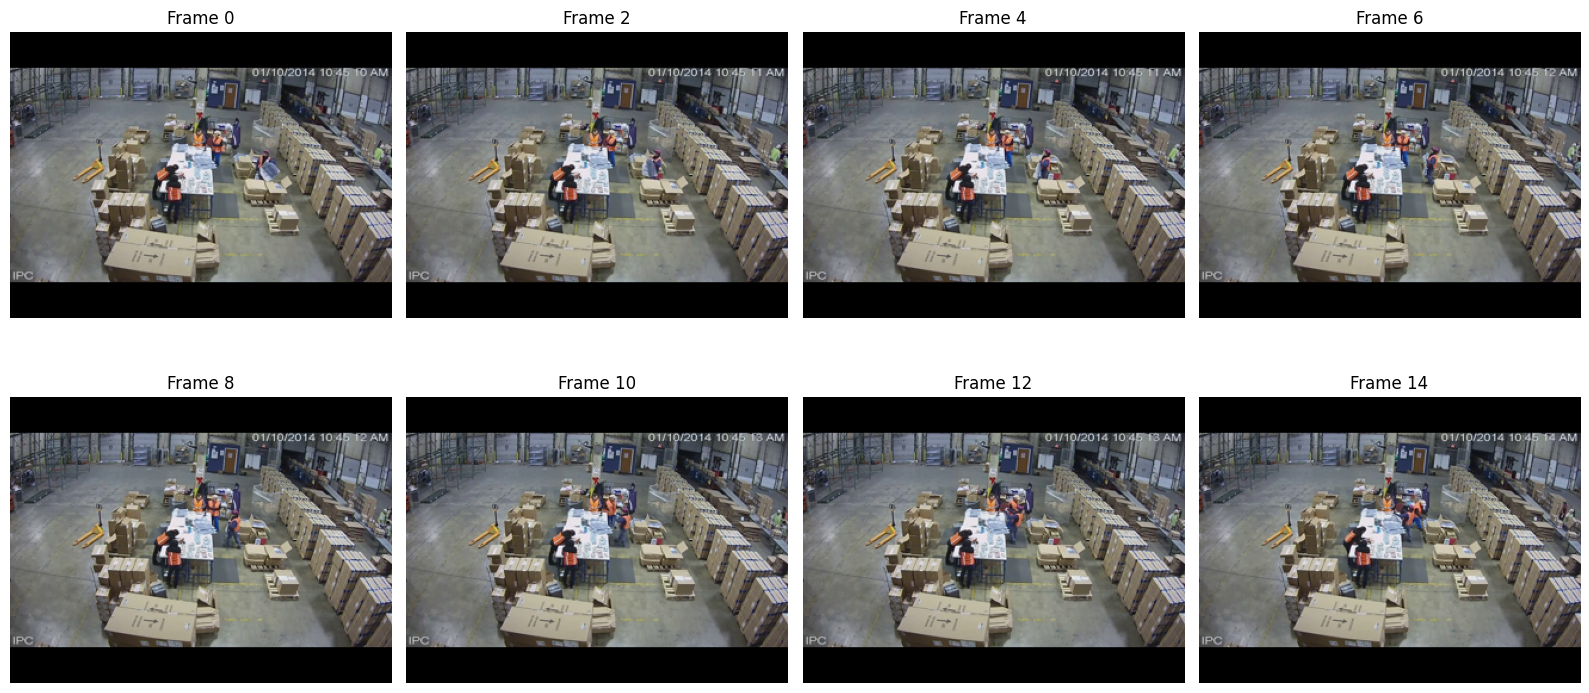

Video: Normal_Videos293_x264.mp4
Clip: 0.0 → 4.0
Label: 0


In [24]:
# ============================================================
# 26. Visualize one generated clip
# ============================================================

sample = train_clips.iloc[0]

frames = read_clip_frames(
    sample["video_path"],
    sample["start_sec"],
    sample["end_sec"]
)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, frame, idx in zip(axes.ravel(), frames[::2], range(0, 16, 2)):
    ax.imshow(frame)
    ax.set_title(f"Frame {idx}")
    ax.axis("off")

plt.tight_layout()
plt.show()

print("Video:", sample["video_filename"])
print("Clip:", sample["start_sec"], "→", sample["end_sec"])
print("Label:", sample["clip_label"])

In [25]:
# ============================================================
# 27. Run ONE real clip through VideoMAE
#     This is the critical shape-checking step.
# ============================================================

frames = read_clip_frames(
    sample["video_path"],
    sample["start_sec"],
    sample["end_sec"]
)

inputs = processor(
    frames,
    return_tensors="pt"
)

inputs = {
    k: v.to(DEVICE)
    for k, v in inputs.items()
}

print("Processor outputs:")
for k, v in inputs.items():
    print(k, tuple(v.shape), v.dtype)

with torch.no_grad():
    with torch.autocast(
        device_type="cuda",
        dtype=torch.float16,
        enabled=(DEVICE.type == "cuda")
    ):
        outputs = model(
            **inputs,
            output_hidden_states=True,
            return_dict=True
        )

print("\nLogits shape:", tuple(outputs.logits.shape))

print("\nNumber of hidden-state tensors:",
      len(outputs.hidden_states))

for i, h in enumerate(outputs.hidden_states):
    print(f"hidden_states[{i}] shape:", tuple(h.shape))

LAST_HIDDEN = outputs.hidden_states[-1]

print("\nACTUAL LAST HIDDEN STATE SHAPE:")
print(tuple(LAST_HIDDEN.shape))

Processor outputs:
pixel_values (1, 16, 3, 224, 224) torch.float32

Logits shape: (1, 400)

Number of hidden-state tensors: 13
hidden_states[0] shape: (1, 1568, 768)
hidden_states[1] shape: (1, 1568, 768)
hidden_states[2] shape: (1, 1568, 768)
hidden_states[3] shape: (1, 1568, 768)
hidden_states[4] shape: (1, 1568, 768)
hidden_states[5] shape: (1, 1568, 768)
hidden_states[6] shape: (1, 1568, 768)
hidden_states[7] shape: (1, 1568, 768)
hidden_states[8] shape: (1, 1568, 768)
hidden_states[9] shape: (1, 1568, 768)
hidden_states[10] shape: (1, 1568, 768)
hidden_states[11] shape: (1, 1568, 768)
hidden_states[12] shape: (1, 1568, 768)

ACTUAL LAST HIDDEN STATE SHAPE:
(1, 1568, 768)


In [26]:
# ============================================================
# 29. Convert VideoMAE output to a fixed-size feature vector
# ============================================================

def pool_videomae_output(outputs):
    hidden = outputs.hidden_states[-1]

    if hidden.ndim == 2:
        # Already [B, D]
        features = hidden

    elif hidden.ndim == 3:
        # [B, N, D]
        if hidden.shape[1] < 2:
            features = hidden[:, 0, :]
        else:
            # VideoMAE classification representation: CLS token.
            features = hidden[:, 0, :]

    else:
        raise ValueError(
            f"Unexpected VideoMAE hidden-state shape: {tuple(hidden.shape)}"
        )

    return features

test_feature = pool_videomae_output(outputs)

print("Feature shape:", tuple(test_feature.shape))
print("Feature dimension:", test_feature.shape[-1])

Feature shape: (1, 768)
Feature dimension: 768


In [27]:
# ============================================================
# 30. Feature extraction for one clip
# ============================================================

def extract_one_clip_feature(video_path, start_sec, end_sec):
    frames = read_clip_frames(
        video_path,
        start_sec,
        end_sec
    )

    inputs = processor(
        frames,
        return_tensors="pt"
    )

    inputs = {
        k: v.to(DEVICE)
        for k, v in inputs.items()
    }

    with torch.no_grad():
        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(DEVICE.type == "cuda")
        ):
            outputs = model(
                **inputs,
                output_hidden_states=True,
                return_dict=True
            )

    feature = pool_videomae_output(outputs)

    return feature.squeeze(0).float().cpu().numpy()

In [28]:
# ============================================================
# 31. Test feature extraction
# ============================================================

feature = extract_one_clip_feature(
    sample["video_path"],
    sample["start_sec"],
    sample["end_sec"]
)

print("Feature dtype:", feature.dtype)
print("Feature shape:", feature.shape)
print("First 10 values:", feature[:10])

Feature dtype: float32
Feature shape: (768,)
First 10 values: [-6.59375    -0.4494629  -0.42504883  0.31835938  0.7128906   1.1640625
  2.1992188   1.0273438  -1.4238281   4.515625  ]


In [29]:
# ============================================================
# 33. Stable ID for a source video
# ============================================================

import hashlib

def video_id(video_path):
    # Hash the relative path so duplicate filenames in different folders
    # cannot overwrite each other.
    rel = str(Path(video_path).relative_to(DATASET_ROOT))
    return hashlib.md5(rel.encode("utf-8")).hexdigest()[:16]

print(video_id(sample["video_path"]))

2cb8b8637ee4aa5f


In [30]:
# ============================================================
# 34. Extract and save features for one source video
# ============================================================

def extract_video_features(video_clip_df, split):
    assert len(video_clip_df) > 0

    video_path = video_clip_df.iloc[0]["video_path"]
    vid = video_id(video_path)

    out_file = FEATURE_ROOT / split / f"{vid}.npz"

    # RESUME: skip a video that has already been completed.
    if out_file.exists():
        return "skipped", out_file

    feature_list = []
    clip_ids = []
    starts = []
    ends = []
    labels = []
    overlaps = []

    for _, row in video_clip_df.iterrows():
        try:
            feat = extract_one_clip_feature(
                row["video_path"],
                float(row["start_sec"]),
                float(row["end_sec"])
            )

            feature_list.append(feat)
            clip_ids.append(int(row["clip_id"]))
            starts.append(float(row["start_sec"]))
            ends.append(float(row["end_sec"]))
            labels.append(int(row["clip_label"]))

            overlap = row["annotation_overlap"]
            overlaps.append(
                float(overlap) if pd.notna(overlap) else np.nan
            )

        except Exception as e:
            print(
                f"ERROR: {row['video_filename']} "
                f"clip {row['clip_id']}: {e}"
            )
            raise

    features = np.stack(feature_list).astype(np.float32)

    np.savez_compressed(
        out_file,
        features=features,
        clip_id=np.asarray(clip_ids, dtype=np.int32),
        start_sec=np.asarray(starts, dtype=np.float32),
        end_sec=np.asarray(ends, dtype=np.float32),
        clip_label=np.asarray(labels, dtype=np.int8),
        annotation_overlap=np.asarray(overlaps, dtype=np.float32),
    )

    return "saved", out_file

In [31]:
# ============================================================
# 35. Group clips by source video
# ============================================================

def group_clips_by_video(clip_df):
    return [
        group
        for _, group in clip_df.groupby(
            "video_filename",
            sort=False
        )
    ]

train_groups = group_clips_by_video(train_clips)
val_groups = group_clips_by_video(val_clips)
test_groups = group_clips_by_video(test_clips)

print("Train source videos:", len(train_groups))
print("Val source videos  :", len(val_groups))
print("Test source videos :", len(test_groups))

Train source videos: 680
Val source videos  : 120
Test source videos : 290


In [32]:
# ============================================================
# 36. Run TRAIN extraction
#
# WARNING:
# This is the expensive GPU step.
# It may take a long time on Kaggle.
# ============================================================

def run_split_extraction(clip_df, split):
    groups = group_clips_by_video(clip_df)

    saved = 0
    skipped = 0

    for i, group in enumerate(groups, 1):
        status, out_file = extract_video_features(group, split)

        if status == "saved":
            saved += 1
        else:
            skipped += 1

        if i % 10 == 0 or i == len(groups):
            print(
                f"{split}: {i}/{len(groups)} videos | "
                f"saved={saved}, skipped={skipped}"
            )

    return saved, skipped

In [33]:
from pathlib import Path
import shutil

# Find the attached 410-feature dataset automatically
candidates = list(
    Path("/kaggle/input").rglob("ucf_videomae/features/train")
)

print("Candidate feature folders:")
for x in candidates:
    print(x)

if not candidates:
    raise FileNotFoundError(
        "Could not find ucf_videomae/features/train in /kaggle/input"
    )

OLD_TRAIN = candidates[0]

# This MUST match the FEATURE_ROOT used by your extractor
NEW_TRAIN = Path("/kaggle/working/ucf_videomae/features/train")
NEW_TRAIN.mkdir(parents=True, exist_ok=True)

old_files = list(OLD_TRAIN.glob("*.npz"))

print(f"\nFound {len(old_files)} existing feature files.")

# Copy previous features into writable storage
copied = 0

for src in old_files:
    dst = NEW_TRAIN / src.name

    if not dst.exists():
        shutil.copy2(src, dst)
        copied += 1

print(f"Copied: {copied}")
print(f"Total in working/train: {len(list(NEW_TRAIN.glob('*.npz')))}")

Candidate feature folders:
/kaggle/input/datasets/zunzurkarchaitanya/540-videos-feature-map/ucf_videomae/features/train

Found 541 existing feature files.
Copied: 0
Total in working/train: 541


In [34]:
# Run this when you are ready:
train_saved, train_skipped = run_split_extraction(train_clips, "train")

train: 10/680 videos | saved=0, skipped=10
train: 20/680 videos | saved=0, skipped=20
train: 30/680 videos | saved=0, skipped=30
train: 40/680 videos | saved=0, skipped=40
train: 50/680 videos | saved=0, skipped=50
train: 60/680 videos | saved=0, skipped=60
train: 70/680 videos | saved=0, skipped=70
train: 80/680 videos | saved=0, skipped=80
train: 90/680 videos | saved=0, skipped=90
train: 100/680 videos | saved=0, skipped=100
train: 110/680 videos | saved=0, skipped=110
train: 120/680 videos | saved=0, skipped=120
train: 130/680 videos | saved=0, skipped=130
train: 140/680 videos | saved=0, skipped=140
train: 150/680 videos | saved=0, skipped=150
train: 160/680 videos | saved=0, skipped=160
train: 170/680 videos | saved=0, skipped=170
train: 180/680 videos | saved=0, skipped=180
train: 190/680 videos | saved=0, skipped=190
train: 200/680 videos | saved=0, skipped=200
train: 210/680 videos | saved=0, skipped=210
train: 220/680 videos | saved=0, skipped=220
train: 230/680 videos | save

In [35]:
# ============================================================
# 37. Run VALIDATION extraction
# ============================================================

# Run after TRAIN extraction:
val_saved, val_skipped = run_split_extraction(val_clips, "val")

val: 10/120 videos | saved=10, skipped=0
val: 20/120 videos | saved=20, skipped=0
val: 30/120 videos | saved=30, skipped=0
val: 40/120 videos | saved=40, skipped=0
val: 50/120 videos | saved=50, skipped=0
val: 60/120 videos | saved=60, skipped=0
val: 70/120 videos | saved=70, skipped=0
val: 80/120 videos | saved=80, skipped=0
val: 90/120 videos | saved=90, skipped=0
val: 100/120 videos | saved=100, skipped=0
val: 110/120 videos | saved=110, skipped=0
val: 120/120 videos | saved=120, skipped=0


In [36]:
# ============================================================
# 38. Run TEST extraction
# ============================================================

# Run after VALIDATION extraction:
test_saved, test_skipped = run_split_extraction(test_clips, "test")

test: 10/290 videos | saved=10, skipped=0
test: 20/290 videos | saved=20, skipped=0
test: 30/290 videos | saved=30, skipped=0
test: 40/290 videos | saved=40, skipped=0
test: 50/290 videos | saved=50, skipped=0
test: 60/290 videos | saved=60, skipped=0
test: 70/290 videos | saved=70, skipped=0
test: 80/290 videos | saved=80, skipped=0
test: 90/290 videos | saved=90, skipped=0
test: 100/290 videos | saved=100, skipped=0
test: 110/290 videos | saved=110, skipped=0
test: 120/290 videos | saved=120, skipped=0
test: 130/290 videos | saved=130, skipped=0
test: 140/290 videos | saved=140, skipped=0
test: 150/290 videos | saved=150, skipped=0
test: 160/290 videos | saved=160, skipped=0
test: 170/290 videos | saved=170, skipped=0
test: 180/290 videos | saved=180, skipped=0
test: 190/290 videos | saved=190, skipped=0
test: 200/290 videos | saved=200, skipped=0
test: 210/290 videos | saved=210, skipped=0
test: 220/290 videos | saved=220, skipped=0
test: 230/290 videos | saved=230, skipped=0
test: 

In [37]:
# ============================================================
# 40. Validate saved feature files
# ============================================================

def inspect_saved_features(split):
    files = sorted((FEATURE_ROOT / split).glob("*.npz"))

    print(f"\n{split.upper()}")
    print("Feature files:", len(files))

    if not files:
        print("No files found yet.")
        return None

    dimensions = set()
    total_clips = 0

    for f in files[:20]:
        data = np.load(f)
        dimensions.add(data["features"].shape[1])
        total_clips += data["features"].shape[0]

    print("Feature dimensions seen in first 20 files:", dimensions)

    return files

train_feature_files = inspect_saved_features("train")
val_feature_files = inspect_saved_features("val")
test_feature_files = inspect_saved_features("test")


TRAIN
Feature files: 680
Feature dimensions seen in first 20 files: {768}

VAL
Feature files: 120
Feature dimensions seen in first 20 files: {768}

TEST
Feature files: 290
Feature dimensions seen in first 20 files: {768}


In [38]:
# ============================================================
# 41. Final metadata summary
# ============================================================

summary = pd.DataFrame({
    "split": ["train", "val", "test"],
    "videos": [
        train_clips["video_filename"].nunique(),
        val_clips["video_filename"].nunique(),
        test_clips["video_filename"].nunique()
    ],
    "clips": [
        len(train_clips),
        len(val_clips),
        len(test_clips)
    ],
    "anomaly_clips": [
        int((train_clips["clip_label"] == 1).sum()),
        int((val_clips["clip_label"] == 1).sum()),
        int((test_clips["clip_label"] == 1).sum())
    ],
    "normal_clips": [
        int((train_clips["clip_label"] == 0).sum()),
        int((val_clips["clip_label"] == 0).sum()),
        int((test_clips["clip_label"] == 0).sum())
    ],
})

display(summary)

,split,videos,clips,anomaly_clips,normal_clips
0,train,680,139564,0,139564
1,val,120,17206,0,17206
2,test,290,18100,12034,6066
